In [273]:
"""
03_dimensionality_reduction.ipynb
==================================
Applies feature selection and linear transformation to preprocessed profiles.
Follows Step 2 of the analysis pipeline.

Inputs:
    - outputs/01_preprocessed_features.csv (preprocessed output from 02_preprocess.ipynb)

Outputs:
    - TBD
"""

'\n03_dimensionality_reduction.ipynb\n==================================\nApplies feature selection and linear transformation to preprocessed profiles.\nFollows Step 2 of the analysis pipeline.\n\nInputs:\n    - outputs/01_preprocessed_features.csv (preprocessed output from 02_preprocess.ipynb)\n\nOutputs:\n    - TBD\n'

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.filters import threshold_otsu
from sklearn.mixture import GaussianMixture
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
df = pd.read_csv(OUTPUT_DIR / "01_preprocessed_features.csv")

meta_cols = ["plate_name", "session", "batch", "row", "column", "compound", "dose_uM", "cell_type", "condition", "num_wells"]
original_feature_cols = [c for c in df.columns if c not in meta_cols]

In [275]:
"""
NOTE: the following function placeholders are just rough ideas corresponding to the steps. 
Please feel free to adjust or add anything, I can integrate later :)
"""

'\nNOTE: the following function placeholders are just rough ideas corresponding to the steps. \nPlease feel free to adjust or add anything, I can integrate later :)\n'

In [276]:
# Ideas for helper functions for 2a. Feature Selection (variance thresholding and correlation filtering)

def variance_threshold(df, feature_cols, threshold=0.1, method='mad'):
    """
    Removes near-zero variance features as a first pass before more expensive filtering methods (Step 2a).
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        threshold: threshold below which features are removed (default 0.1)
        method: 'mad' (recommended) or 'std'
    
    Returns:
        retained: filtered list of feature column names
    """
    all_scores = pd.DataFrame(index=feature_cols)
    all_scores['std'] = df[feature_cols].std()
    all_scores['mad'] = df[feature_cols].apply(lambda x: (x - x.median()).abs().median())

    if method == 'std':
        scores = all_scores['std']
    elif method == 'mad':
        scores = all_scores['mad']
    else:
        raise ValueError("method must be 'std' or 'mad'")
    
    removed = scores[scores < threshold].index.tolist()
    retained = scores[scores >= threshold].index.tolist()
    
    print(f"Variance thresholding ({method} < {threshold}):")
    print(f"  Input features:   {len(feature_cols)}")
    print(f"  Retained:         {len(retained)}")
    
    if removed:
        print(f"\n  Removed {len(removed)} features with {method} < {threshold}:")
        removed_df = all_scores.loc[removed].sort_values(by=method)
        
        for row in removed_df.itertuples():
            print(f"    {row.Index:<120} (std={row.std:.4f}, mad={row.mad:.4f})")
    
    return retained

def correlation_filter(df, feature_cols, threshold=0.95):
    """
    Removes redundant features via iterative correlation filtering (Step 2a).
    At each step, removes the feature with the highest mean absolute correlation
    to all others when any pair exceeds the threshold.
    Report how many features remain after filtering.
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        threshold: correlation threshold (default 0.95)
    
    Returns:
        filtered list of feature column names
    """
    print(f"Starting correlation filtering (threshold={threshold})...")
    
    # 1. Compute initial absolute correlation matrix
    corr_matrix = df[feature_cols].corr().abs()
    
    # Fill diagonal with 0 so a feature doesn't correlate with itself during the mean calculation
    np.fill_diagonal(corr_matrix.values, 0)
    
    current_features = list(feature_cols)
    removed_count = 0

    while True:
        # 2. Find pairs that exceed the threshold (check upper triangle)
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        bad_pairs = np.where(upper > threshold)
        
        # If no pairs exceed threshold, we are done
        if len(bad_pairs[0]) == 0:
            break
            
        # 3. Identify all features involved in at least one 'bad' pair
        # We don't want to calculate the mean for EVERY feature, just ones in a highly correlated pair
        guilty_indices = np.unique(np.concatenate([bad_pairs[0], bad_pairs[1]]))
        guilty_features = corr_matrix.index[guilty_indices]
        
        # 4. Find which 'guilty' feature has the highest mean correlation to ALL others (most "globally redundant" feature)
        mean_corrs = corr_matrix.loc[guilty_features].mean(axis=1)
        feature_to_drop = mean_corrs.idxmax()
        
        # 5. Remove the feature from the matrix and the list
        corr_matrix = corr_matrix.drop(index=feature_to_drop, columns=feature_to_drop)
        current_features.remove(feature_to_drop)
        removed_count += 1
        
        # Update progress every 50 features removed
        if removed_count % 50 == 0:
            print(f"  Removed {removed_count} features... {len(current_features)} remaining", end="\r")

    print(f"\nFiltering complete.")
    print(f"  Input features   : {len(feature_cols)}")
    print(f"  Removed          : {removed_count}")
    print(f"  Retained         : {len(current_features)}")
    
    return current_features

def replicate_correlation_filter(df, feature_cols):
    """
    Removes features that are inconsistent across biological replicates (Step 2a).
    Uses NEG CTRL wells as replicates — healthy wells and disease wells should each
    be morphologically identical within a plate.
    Work at the plate level to avoid cross-plate batch effects.
    Compare retained feature set to correlation filtering alone.
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
    
    Returns:
        filtered list of feature column names
    """
    pass

In [277]:
# Helper functions for 2a. Feature Selection (Cohen's d based)

def _threshold_otsu(d_values):
    """
    Otsu threshold on |d| distribution. Assumes bimodality — |d| histogram should show clear valley.
    """
    return float(threshold_otsu(d_values))

def _threshold_gmm(d_values):
    """
    Fit a 2-component GMM to |d| and return the crossing point.
    More flexible than Otsu — does not require clean bimodality.
    Falls back to component mean midpoint if no crossing is found.
    """
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(d_values.reshape(-1, 1))

    means = gmm.means_.flatten()
    lo, hi = means.min(), means.max()

    # Scan for the point where posterior probability flips
    x_scan = np.linspace(lo, hi, 10_000).reshape(-1, 1)
    posteriors = gmm.predict_proba(x_scan)
    crossings = np.where(np.diff(np.argmax(posteriors, axis=1)))[0]

    if len(crossings) > 0:
        threshold = float(x_scan[crossings[0], 0])
    else:
        threshold = float((lo + hi) / 2)
        print("  GMM: no crossing found, using component midpoint as fallback.")

    print(f"  GMM component means: {lo:.3f}, {hi:.3f} → threshold: {threshold:.3f}")
    return threshold

def _threshold_permutation(healthy, disease, feature_cols, n_permutations=1000, percentile=95):
    """
    Build a null |d| distribution by permuting healthy/disease labels.
    Uses max |d| per permutation to control family-wise error rate.

    Returns:
        threshold: float
        null_max_d: array of per-permutation max |d| values (for plotting)
    """
    rng = np.random.default_rng(2026)

    combined = np.concatenate([healthy[feature_cols].values,
                                disease[feature_cols].values], axis=0)
    n_h, n_d = len(healthy), len(disease)
    n_total = n_h + n_d

    null_max_d = np.empty(n_permutations)

    for i in range(n_permutations):
        idx = rng.permutation(n_total)
        h_perm = combined[idx[:n_h]]
        d_perm = combined[idx[n_h:]]

        mean_diff = d_perm.mean(axis=0) - h_perm.mean(axis=0)
        var_h = h_perm.var(axis=0, ddof=1)
        var_d = d_perm.var(axis=0, ddof=1)
        pooled = np.sqrt(((n_h - 1) * var_h + (n_d - 1) * var_d) / (n_h + n_d - 2))
        pooled = np.where(pooled < 1e-10, np.nan, pooled)

        abs_d = np.abs(mean_diff / pooled)
        null_max_d[i] = np.nanmax(abs_d)

        if (i + 1) % 200 == 0:
            print(f"  Permutation {i + 1}/{n_permutations}...", end="\r")

    print()
    threshold = float(np.percentile(null_max_d, percentile))
    print(f"  Permutation null ({percentile}th pct of max |d|): {threshold:.3f}")
    return threshold, null_max_d


def cohen_d_filter(df, feature_cols, level=None, method='permutation', n_permutations=1000, percentile=95):
    """
    Select features that discriminate healthy from disease using Cohen's d.

    level : None | 'session' | 'batch' | 'plate_name'
        None  → compute d globally (recommended when batch effects are negligible).
        Other → compute d per group, average across groups, then threshold.
        NOTE: if using per-group d but a single global PCA, feature selection
        is group-aware while the coordinate system remains comparable. If you
        also fit PCA per group, rescue scores are within-group only.

    method : 'permutation' (default) | 'gmm' | 'otsu'
        permutation — most principled; no distributional assumptions; controls FWER.
        gmm         — flexible; good for right-skewed / overlapping distributions.
        otsu        — assumes bimodality; use if histogram shows a clear valley.
    """
    def _compute_d(h: pd.DataFrame, d: pd.DataFrame) -> pd.Series:
        n_h, n_d = len(h), len(d)
        var_h = h[feature_cols].var(ddof=1)
        var_d = d[feature_cols].var(ddof=1)
        pooled = np.sqrt(((n_h - 1) * var_h + (n_d - 1) * var_d) / (n_h + n_d - 2))
        pooled = pooled.replace(0, np.nan)
        return ((d[feature_cols].mean() - h[feature_cols].mean()) / pooled).abs()

    # 1. Compute Cohen's d
    d_records: dict[str, pd.Series] = {}

    if level is None:
        healthy = df[df["condition"] == "healthy"]
        disease = df[df["condition"] == "disease"]
        print(f"Global: healthy={len(healthy)}, disease={len(disease)}")
        d_records["global_d"] = _compute_d(healthy, disease)
        score_col = "global_d"
    else:
        for group in sorted(df[level].unique()):
            g = df[df[level] == group]
            h = g[g["condition"] == "healthy"]
            d = g[g["condition"] == "disease"]
            if len(h) < 3 or len(d) < 3:
                print(f"  Skipping {group}: healthy={len(h)}, disease={len(d)}")
                continue
            print(f"  {group}: healthy={len(h)}, disease={len(d)}")
            d_records[str(group)] = _compute_d(h, d)
        d_df_tmp = pd.DataFrame(d_records)
        d_records["mean_d"] = d_df_tmp.mean(axis=1)
        score_col = "mean_d"

    d_df = pd.DataFrame(d_records)
    scores = d_df[score_col].dropna().values

    # 2. Threshold
    null_dist = None  # only populated for permutation

    if method == "otsu":
        threshold = _threshold_otsu(scores)
    elif method == "gmm":
        threshold = _threshold_gmm(scores)
    elif method == "permutation":
        # Always use globally pooled controls for the permutation reference
        healthy_all = df[df["condition"] == "healthy"]
        disease_all = df[df["condition"] == "disease"]
        threshold, null_dist = _threshold_permutation(
            healthy_all, disease_all, feature_cols,
            n_permutations=n_permutations, percentile=percentile,
        )
    else:
        raise ValueError(f"Unknown method '{method}'. Choose: 'otsu', 'gmm', 'permutation'.")

    retained = d_df.index[d_df[score_col] >= threshold].tolist()

    print(f"\nCohen's d filter — method={method}, level={level}")
    print(f"  Threshold : {threshold:.3f}")
    print(f"  Input     : {len(feature_cols)}")
    print(f"  Retained  : {len(retained)}")
    print(f"  Removed   : {len(feature_cols) - len(retained)}")

    # 3. Visualisation
    fig, ax = plt.subplots(figsize=(12, 4))

    # |d| distribution + threshold
    ax.hist(scores, bins=50, color="steelblue", edgecolor="white", alpha=0.8,
            label=f"n={len(scores)} features")
    ax.axvline(threshold, color="red", linewidth=2,
            label=f"{method} threshold = {threshold:.3f}")

    # Optional: overlay null distribution if provided
    if null_dist is not None:
        ax_twin = ax.twinx()
        ax_twin.hist(null_dist, bins=30, color="orange", alpha=0.35,
                    label="Null max |d|")
        ax_twin.set_ylabel("Permutation count", color="orange", fontsize=10)
        ax_twin.legend(loc="lower right", fontsize=9)

    ax.set_xlabel(f"|Cohen's d| ({score_col})")
    ax.set_ylabel("Feature count")
    ax.set_title(f"Cohen's d — Threshold method={method} (level={level})")
    ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

    return retained, d_df

In [278]:
print("="*60)
print("1. FEATURE SELECTION 1: VARIANCE THRESHOLDING")
print("="*60)
print()

print("Remove near-zero variance features as a first filtering pass.\n")
feature_cols_variance = variance_threshold(df, original_feature_cols, method='mad', threshold=0.1)

1. FEATURE SELECTION 1: VARIANCE THRESHOLDING

Remove near-zero variance features as a first filtering pass.

Variance thresholding (mad < 0.1):
  Input features:   2124
  Retained:         2055

  Removed 69 features with mad < 0.1:
    Nuclei - CellPainting Ring Region Sapphire Profile 2/2 SER-Valley - Median per Well                                      (std=1.1784, mad=0.0000)
    Nuclei - CellPainting Ring Region Sapphire Profile 2/2 SER-Dark - Median per Well                                        (std=1.1060, mad=0.0000)
    Nuclei - CellPainting Nucleus Region PhenoVue Fluor 555 Threshold Compactness 60% SER-Spot - Median per Well             (std=1.0005, mad=0.0000)
    Nuclei - CellPainting Nucleus Region Sapphire SER Hole 2 px - Median per Well                                            (std=0.0000, mad=0.0000)
    Nuclei - CellPainting Nucleus Region Sapphire Profile 2/2 SER-Hole - Median per Well                                     (std=0.0000, mad=0.0000)
    Nuclei - Cel

In [279]:
print("="*60)
print("2. FEATURE SELECTION 2: CORRELATION FILTERING")
print("="*60)
print()

print("Remove redundant features via iterative correlation filtering as a second filtering pass.\n")
feature_cols_corr = correlation_filter(df, feature_cols_variance, threshold=0.95)

2. FEATURE SELECTION 2: CORRELATION FILTERING

Remove redundant features via iterative correlation filtering as a second filtering pass.

Starting correlation filtering (threshold=0.95)...
  Removed 1250 features... 805 remainingg
Filtering complete.
  Input features   : 2055
  Removed          : 1279
  Retained         : 776


3. FEATURE SELECTION 3: COHEN'S D BASED FILTERING

Remove features that do not discriminate healthy from disease based on Cohen's d.
Global: healthy=108, disease=108
  GMM component means: 0.355, 1.871 → threshold: 0.681

Cohen's d filter — method=gmm, level=None
  Threshold : 0.681
  Input     : 776
  Retained  : 580
  Removed   : 196


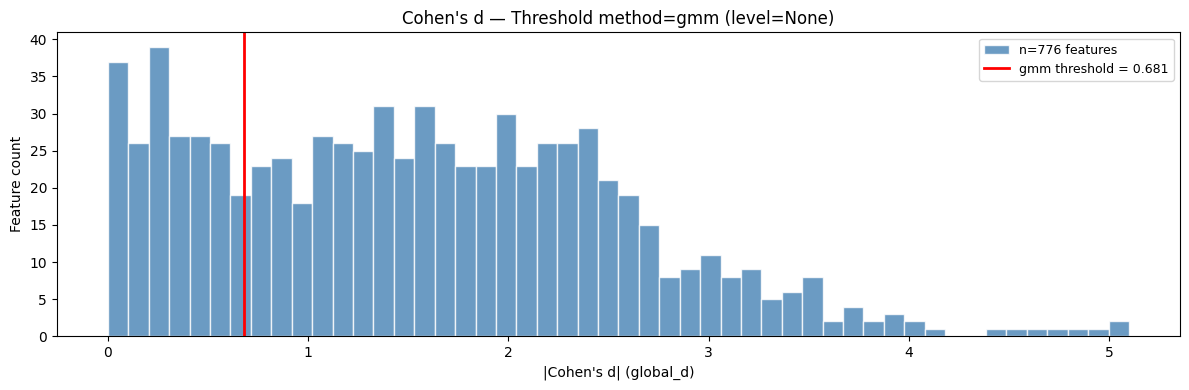

In [280]:
print("="*60)
print("3. FEATURE SELECTION 3: COHEN'S D BASED FILTERING")
print("="*60)
print()

print("Remove features that do not discriminate healthy from disease based on Cohen's d.")
feature_cols_cohens, d_df = cohen_d_filter(df, feature_cols_corr, level=None, method='gmm')
df_filtered = df[meta_cols + feature_cols_cohens]

In [281]:
# Ideas for helper functions for 2b. Linear Transformation

from sklearn.decomposition import PCA

def fit_pca(df, feature_cols, variance_threshold=0.90, plot=True):
    """
    Fits PCA on healthy and disease wells only, then projects all conditions (Step 2b).
    Fitting on controls only prevents compound variance from rotating the disease axis.
    Retain enough PCs to explain ~90% cumulative variance (treat as tunable).
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
    
    Returns:
        df with PCA scores added, fitted PCA object
    """
    # 1. Separate fit data (controls) from transform data (everything)
    df_controls = df[df["condition"].isin(["healthy", "disease"])]
    X_fit = df_controls[feature_cols].values
    X_all = df[feature_cols].values
    
    print(f"Fitting PCA on {len(df_controls)} control wells...")
    
    # 2. Fit PCA
    pca = PCA(n_components=variance_threshold, random_state=2026)
    pca.fit(X_fit)
    
    # 3. Project all data into the new space
    X_pca = pca.transform(X_all)
    
    # 4. Create output DataFrame
    pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    df_pca_values = pd.DataFrame(X_pca, columns=pc_cols, index=df.index)
    
    # Join with original metadata (all columns not in feature_cols)
    meta_cols = [c for c in df.columns if c not in feature_cols]
    df_out = pd.concat([df[meta_cols], df_pca_values], axis=1)
    
    print(f"PCA Complete:")
    print(f"  Components retained: {pca.n_components_}")
    print(f"  Variance explained : {pca.explained_variance_ratio_.sum():.2%}")
    
    # 5. visualize PCA plot
    if plot and X_pca.shape[1] >= 2:
        plt.figure(figsize=(10, 6))
        
        # Plot treatment groups in light gray (bottom layer)
        sns.scatterplot(
            data=df_out[df_out["condition"] == "treatment"],
            x="PC1", y="PC2", color="lightgray", alpha=1, label="Treatment", s=45
        )
        
        # Plot controls on top
        sns.scatterplot(
            data=df_out[df_out["condition"].isin(["healthy", "disease"])],
            x="PC1", y="PC2", hue="condition", style="condition", 
            palette={"healthy": "blue", "disease": "red"}, s=80, edgecolor="black"
        )
        
        plt.title(f"PCA Space (PC1 vs PC2)\nFitted on Controls Only ({variance_threshold*100}% Var)")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        
    return df_out, pca

def apply_sphering(df, pca_cols):
    """
    Applies ZCA whitening (sphering) fitted on healthy wells only (Step 2b).
    Transforms the PCA space so features have equal variance and are uncorrelated,
    with the healthy state defining the geometry.
    Confirm healthy wells form a roughly spherical cloud in the first 2 PCs after whitening.
    
    Args:
        df: profiles dataframe with PCA scores
        pca_cols: list of PC column names
    
    Returns:
        df with sphered PCA scores
    """
    pass

4. DIMENSIONALITY REDUCTION: PCA (ON ONE PLATE)
Fitting PCA on 36 control wells...
PCA Complete:
  Components retained: 4
  Variance explained : 95.16%


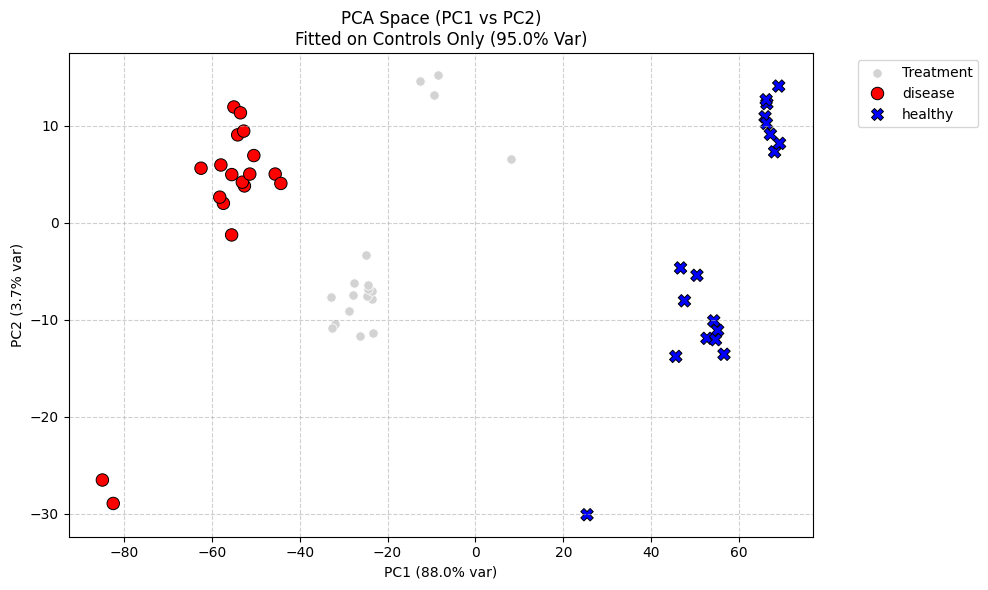

Explained variance by PC1: 88.05%
Explained variance by PC2: 3.69%


In [282]:
print("="*60)
print("4. DIMENSIONALITY REDUCTION: PCA (ON ONE PLATE)")
print("="*60)

# NOTE: this is just a quick test to see how PCA looks on a single plate.
# If we have to fit per-plate, we will also have to rerun the Cohen's d feature selection per plate to avoid data leakage.

# select a particular plate from df based on index
df_plate1 = df[df["plate_name"] == df["plate_name"].unique()[12]]

# Call the function using the features retained by Cohen's d (GMM)
_, pca_model = fit_pca(df_plate1, feature_cols_cohens, variance_threshold=0.95)

# Inspect the results
print(f"Explained variance by PC1: {pca_model.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance by PC2: {pca_model.explained_variance_ratio_[1]:.2%}")

4. DIMENSIONALITY REDUCTION: PCA (ON ALL PLATES)
Fitting PCA on 216 control wells...
PCA Complete:
  Components retained: 17
  Variance explained : 95.13%


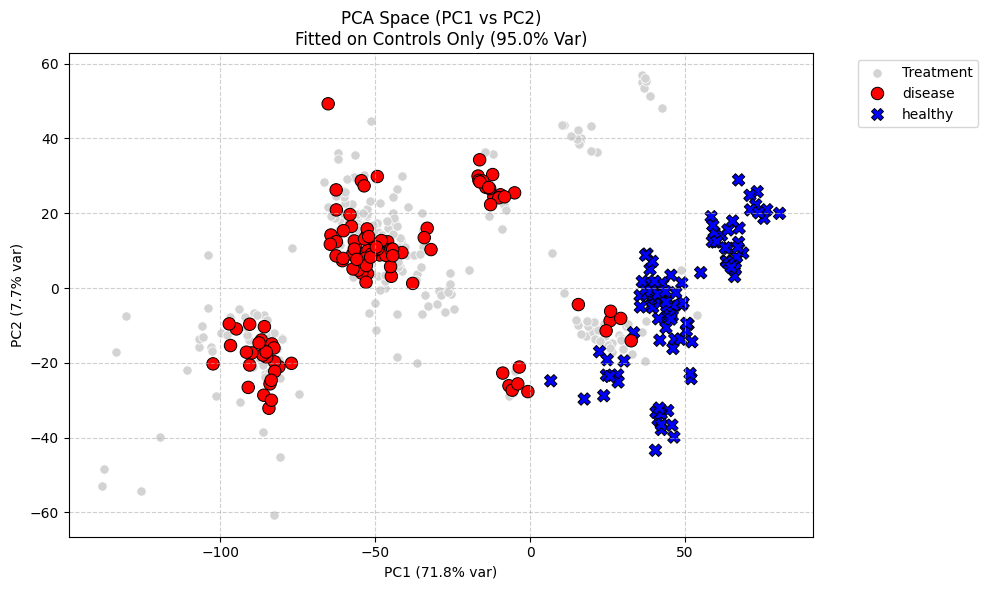

Explained variance by PC1: 71.78%
Explained variance by PC2: 7.68%


In [283]:
print("="*60)
print("4. DIMENSIONALITY REDUCTION: PCA (ON ALL PLATES)")
print("="*60)

# NOTE: we should aim for this plot to have 'disease' and 'healthy' controls in one cluster
# Call the function using the features retained by Cohen's d (GMM)
df_pca, pca_model = fit_pca(df, feature_cols_cohens, variance_threshold=0.95)

# Inspect the results
print(f"Explained variance by PC1: {pca_model.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance by PC2: {pca_model.explained_variance_ratio_[1]:.2%}")